In [1]:
# pandas → 열처리 공정 데이터를 표 형태로 관리
# numpy → 가상의 공정 데이터 생성 및 수치 계산
# matplotlib → 공정 파라미터 관계 시각화

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 실제 공정 CSV가 없으므로 실습용 가상 데이터 생성
# 실행할 때마다 동일한 결과가 나오도록 난수 고정

np.random.seed(42)

# 실습 데이터 개수
n = 120

# 공정 온도 (°C)
temperature = np.random.uniform(
    800,
    1100,
    n
)

# 공정 시간 (min)
process_time = np.random.uniform(
    10,
    120,
    n
)

# 산화 분위기
oxidation_type = np.random.choice(
    ['DRY', 'WET'],
    size=n
)

# 이온 확산과 관련된 초기 Dose를 가정
dose = 10 ** np.random.uniform(
    13,
    15,
    n
)

In [3]:
# 산화 온도와 시간이 증가할수록
# Oxide Thickness가 증가한다고 단순 가정
#
# Wet Oxidation은 Dry Oxidation보다
# 산화 속도가 빠르다고 가정
#
# 아래 식은 Deal-Grove 정확 해석식이 아니라
# 학습용 가상 관계식임

base_rate = np.where(
    oxidation_type == 'WET',
    1.5,
    0.8
)

oxide_thickness = (
    base_rate
    * (temperature - 700)
    * np.sqrt(process_time)
    / 10
    + np.random.normal(0, 10, n)
)

In [4]:
# 확산 공정에서 온도와 시간이 증가할수록
# Junction Depth가 깊어지는 경향을 단순 가정
#
# 실제 확산은 Arrhenius 관계와 확산계수 D를 사용하지만
# 여기서는 데이터 분석 연습용으로 단순화

junction_depth = (
    0.002
    * (temperature - 700)
    * np.sqrt(process_time)
    + np.random.normal(0, 0.1, n)
)

Thermal Budget ≈ T_peak × t_duration

In [5]:
# 열예산 계산
# 실제 공정에서는 단순 곱보다 훨씬 복잡하지만
# 이번 실습에서는 개념 이해용으로 계산

thermal_budget = (
    temperature
    * process_time
)

In [6]:
# 분석용 데이터프레임 생성

df = pd.DataFrame({
    'TEMPERATURE_C': temperature,
    'PROCESS_TIME_MIN': process_time,
    'OXIDATION_TYPE': oxidation_type,
    'DOSE': dose,
    'OXIDE_THICKNESS_NM': oxide_thickness,
    'JUNCTION_DEPTH_UM': junction_depth,
    'THERMAL_BUDGET': thermal_budget
})

df.head()

,TEMPERATURE_C,PROCESS_TIME_MIN,OXIDATION_TYPE,DOSE,OXIDE_THICKNESS_NM,JUNCTION_DEPTH_UM,THERMAL_BUDGET
0,912.362036,98.818417,WET,1.268713e+13,322.896734,4.170687,90158.172156
1,1085.214292,108.570043,WET,1.155339e+14,608.355767,7.921709,117821.762329
2,1019.598183,44.980382,DRY,1.205786e+14,171.354525,4.280657,45861.915989
3,979.597545,22.105712,WET,1.883041e+14,188.213814,2.724666,21654.700916
4,846.805592,35.072868,DRY,2.832583e+14,70.311423,1.640262,29699.900653


In [7]:
# 데이터 크기와 기본 통계 확인

print("데이터 크기:", df.shape)
print(df.columns.tolist())

df.describe()

데이터 크기: (120, 7)
['TEMPERATURE_C', 'PROCESS_TIME_MIN', 'OXIDATION_TYPE', 'DOSE', 'OXIDE_THICKNESS_NM', 'JUNCTION_DEPTH_UM', 'THERMAL_BUDGET']


,TEMPERATURE_C,PROCESS_TIME_MIN,DOSE,OXIDE_THICKNESS_NM,JUNCTION_DEPTH_UM,THERMAL_BUDGET
count,120.000000,120.000000,1.200000e+02,120.000000,120.000000,120.000000
mean,943.133025,63.181269,2.151038e+14,214.930186,3.651856,59163.484247
std,89.348402,31.617277,2.460472e+14,121.922252,1.692155,29684.219853
min,801.656635,10.556774,1.051176e+13,51.119298,1.069757,9883.584526
25%,859.409743,36.298888,3.592427e+13,126.301064,2.278232,33843.121532
50%,944.901578,65.292386,1.051219e+14,180.235154,3.176025,59293.975354
75%,1027.057885,87.583993,3.172179e+14,262.404672,4.702525,84051.972771
max,1096.066081,118.421550,9.572167e+14,635.012487,8.320690,129042.732574


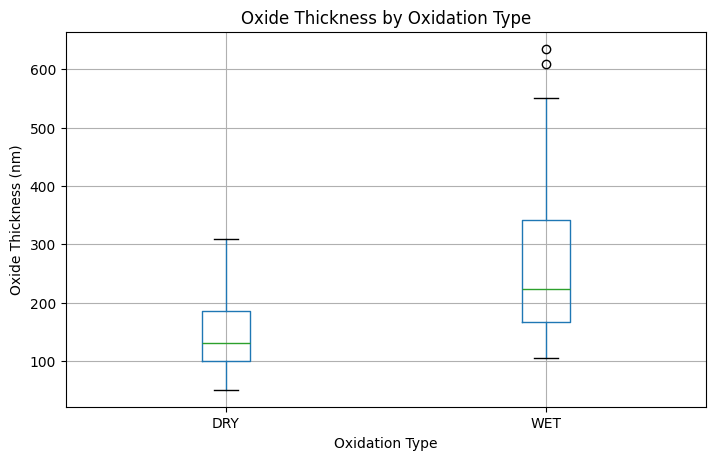

In [8]:
# Dry / Wet Oxidation 방식에 따른
# 산화막 두께 분포 비교

df.boxplot(
    column='OXIDE_THICKNESS_NM',
    by='OXIDATION_TYPE',
    figsize=(8, 5)
)

plt.title('Oxide Thickness by Oxidation Type')
plt.suptitle('')
plt.xlabel('Oxidation Type')
plt.ylabel('Oxide Thickness (nm)')

plt.show()

WET
→ 상대적으로 산화막이 두껍게 형성되는 경향

DRY
→ 상대적으로 성장 속도가 느린 경향

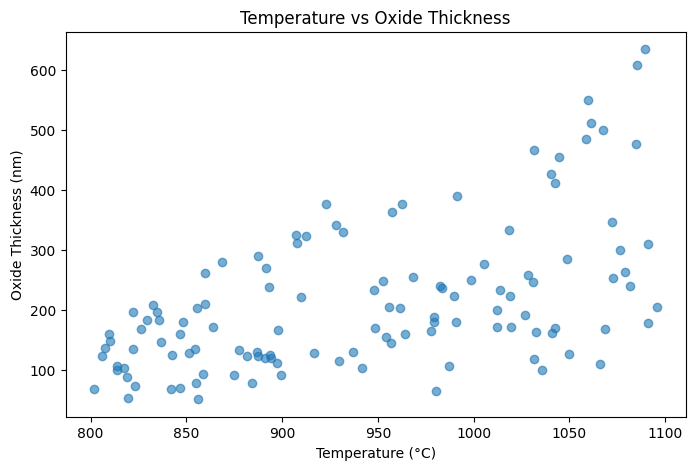

In [9]:
# 공정 온도와 Oxide Thickness 관계 확인

plt.figure(figsize=(8, 5))

plt.scatter(
    df['TEMPERATURE_C'],
    df['OXIDE_THICKNESS_NM'],
    alpha=0.6
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Oxide Thickness (nm)')
plt.title('Temperature vs Oxide Thickness')

plt.show()

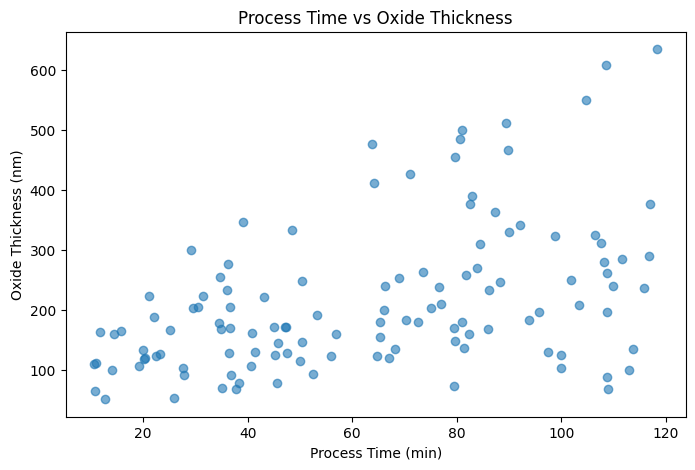

In [10]:
# 공정 시간이 길어질수록
# 산화막 두께가 어떻게 변하는지 확인

plt.figure(figsize=(8, 5))

plt.scatter(
    df['PROCESS_TIME_MIN'],
    df['OXIDE_THICKNESS_NM'],
    alpha=0.6
)

plt.xlabel('Process Time (min)')
plt.ylabel('Oxide Thickness (nm)')
plt.title('Process Time vs Oxide Thickness')

plt.show()

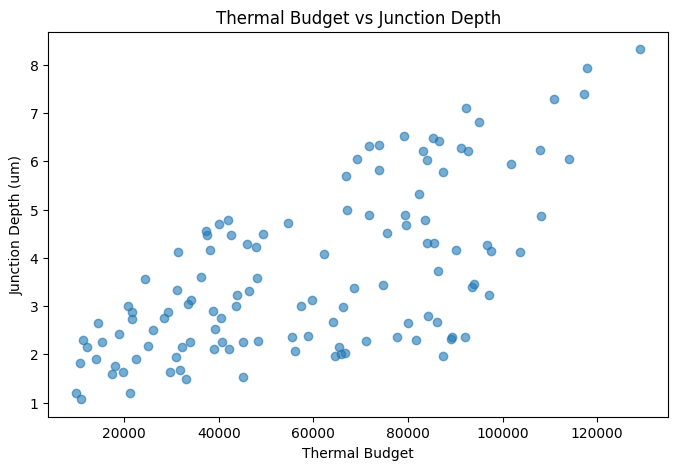

In [11]:
# 열예산이 커질수록
# 도펀트 확산이 증가하여 Junction Depth가
# 깊어지는 경향이 있는지 확인

plt.figure(figsize=(8, 5))

plt.scatter(
    df['THERMAL_BUDGET'],
    df['JUNCTION_DEPTH_UM'],
    alpha=0.6
)

plt.xlabel('Thermal Budget')
plt.ylabel('Junction Depth (um)')
plt.title('Thermal Budget vs Junction Depth')

plt.show()

In [12]:
# 주요 열처리 파라미터 간 상관관계 계산

corr = df[
    [
        'TEMPERATURE_C',
        'PROCESS_TIME_MIN',
        'OXIDE_THICKNESS_NM',
        'JUNCTION_DEPTH_UM',
        'THERMAL_BUDGET'
    ]
].corr()

print("상관행렬:")
print(corr.round(3))

상관행렬:
                    TEMPERATURE_C  PROCESS_TIME_MIN  OXIDE_THICKNESS_NM  \
TEMPERATURE_C               1.000            -0.152               0.553   
PROCESS_TIME_MIN           -0.152             1.000               0.459   
OXIDE_THICKNESS_NM          0.553             0.459               1.000   
JUNCTION_DEPTH_UM           0.755             0.484               0.802   
THERMAL_BUDGET              0.052             0.975               0.597   

                    JUNCTION_DEPTH_UM  THERMAL_BUDGET  
TEMPERATURE_C                   0.755           0.052  
PROCESS_TIME_MIN                0.484           0.975  
OXIDE_THICKNESS_NM              0.802           0.597  
JUNCTION_DEPTH_UM               1.000           0.662  
THERMAL_BUDGET                  0.662           1.000  


In [13]:
# 핵심 관계의 상관계수 확인

corr_temp_oxide = df['TEMPERATURE_C'].corr(
    df['OXIDE_THICKNESS_NM']
)

corr_time_oxide = df['PROCESS_TIME_MIN'].corr(
    df['OXIDE_THICKNESS_NM']
)

corr_budget_junction = df['THERMAL_BUDGET'].corr(
    df['JUNCTION_DEPTH_UM']
)

print(
    f"Temperature vs Oxide Thickness: "
    f"{corr_temp_oxide:.3f}"
)

print(
    f"Process Time vs Oxide Thickness: "
    f"{corr_time_oxide:.3f}"
)

print(
    f"Thermal Budget vs Junction Depth: "
    f"{corr_budget_junction:.3f}"
)

Temperature vs Oxide Thickness: 0.553
Process Time vs Oxide Thickness: 0.459
Thermal Budget vs Junction Depth: 0.662
